In [1]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import joblib

In [2]:
DATA_DIR = "data/processed/mask"
CLASSES = ["fist", "two", "palm"]
IMG_SIZE = (224, 224)

In [3]:
def extract_hu_moments(img):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
        
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        return np.zeros(7)
        
    c = max(contours, key=cv2.contourArea)
    moments = cv2.moments(c)
    hu = cv2.HuMoments(moments).flatten()

    # log scale (quan trọng)
    for i in range(7):
        if hu[i] != 0:
            hu[i] = -1 * np.copysign(1.0, hu[i]) * np.log10(abs(hu[i]))

    return hu

In [4]:
X = []
y = []

for label, cls in enumerate(CLASSES):
    class_dir = os.path.join(DATA_DIR, cls)

    for img_name in tqdm(os.listdir(class_dir), desc=cls):
        path = os.path.join(class_dir, img_name)

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, IMG_SIZE)

        feat = extract_hu_moments(img)

        X.append(feat)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  # (N, 7)
print("y shape:", y.shape)

palm: 100%|██████████| 750/750 [00:00<00:00, 3852.71it/s]

X shape: (2250, 7)
y shape: (2250,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
# 1. Định nghĩa không gian siêu tham số
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Cấu hình Stratified 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Khởi tạo mô hình
rf_base = RandomForestClassifier(random_state=42)

# 4. Khởi tạo GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# 5. Huấn luyện
print("Đang tiến hành GridSearchCV...")
grid_search.fit(X_train, y_train)

# 6. Lấy model tốt nhất và in kết quả
best_rf = grid_search.best_estimator_

print("\n--- KẾT QUẢ GRID SEARCH ---")
print("Best Parameters (best_params_):", grid_search.best_params_)
print("Best Cross-Validation Score (best_score_): {:.4f}".format(grid_search.best_score_))

Đang tiến hành GridSearchCV...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

--- KẾT QUẢ GRID SEARCH ---
Best Parameters (best_params_): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Score (best_score_): 0.9650


In [7]:
# Dùng mô hình tốt nhất (best_rf) để dự đoán
y_pred = best_rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=CLASSES))

              precision    recall  f1-score   support

        fist       0.97      0.97      0.97       150
         two       0.97      0.99      0.98       150
        palm       0.98      0.96      0.97       150

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450



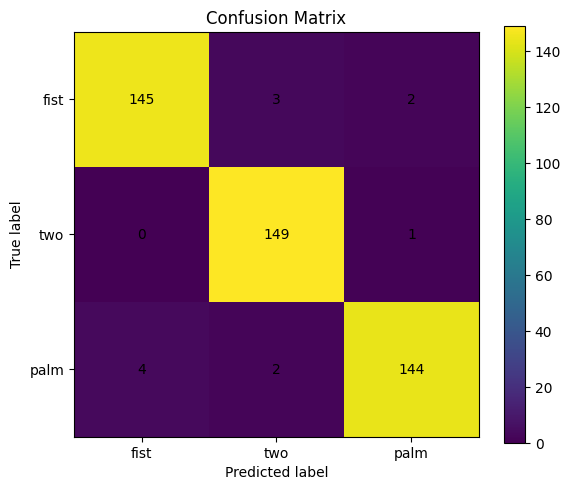

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = range(len(CLASSES))

plt.xticks(tick_marks, CLASSES)
plt.yticks(tick_marks, CLASSES)

# ghi số vào từng ô
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")

plt.tight_layout()
plt.show()

In [9]:
joblib.dump(best_rf, "models/rf_shape_best_cv.pkl")
print("Saved best model!")

Saved best model!


In [10]:
rf_model = joblib.load("models/rf_shape_best_cv.pkl")

def predict_rf(mask):
    feat = extract_hu_moments(mask).reshape(1, -1)
    return int(rf_model.predict(feat)[0])

In [11]:
import glob
import random

MODEL_NAME = "rf_shape_best_cv.pkl"

def predict(img):
    model_path = os.path.join("models", MODEL_NAME)
    model = joblib.load(model_path)
    
    features = extract_hu_moments(img).reshape(1, -1)
    prediction = model.predict(features)[0]
    return prediction

print("--- TEST THỬ HÀM PREDICT VỚI ẢNH NGẪU NHIÊN ---")
class_mapping_reverse = {0: 'fist', 1: 'two', 2: 'palm'}
classes = ['fist', 'two', 'palm']

for cls in classes:
    cls_dir = os.path.join(DATA_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
        
    images = glob.glob(os.path.join(cls_dir, "*.jpg")) + glob.glob(os.path.join(cls_dir, "*.png"))
    
    if len(images) > 0:
        random_img_path = random.choice(images)
        img_name = os.path.basename(random_img_path)
        
        test_img = cv2.imread(random_img_path, cv2.IMREAD_GRAYSCALE)
        pred_label = predict(test_img)
        pred_class_name = class_mapping_reverse[pred_label]
        
        print(f"Ảnh gốc: [{cls}] ({img_name}) ---> Model dự đoán: [{pred_class_name}] (Label: {pred_label})")

--- TEST THỬ HÀM PREDICT VỚI ẢNH NGẪU NHIÊN ---
Ảnh gốc: [fist] (fist_kha_00199.jpg) ---> Model dự đoán: [fist] (Label: 0)
Ảnh gốc: [two] (two_hung_00199.jpg) ---> Model dự đoán: [two] (Label: 1)
Ảnh gốc: [palm] (palm_kha_00158.jpg) ---> Model dự đoán: [palm] (Label: 2)
